# PPT1 Exercise — Foundations of Visualization
### Unit 1: Foundations of Visualization, Data Interpretation (UE24CS342AA9)

**Dataset:** Social Media Sentiment Analysis — AI Trends 2026 (Kaggle)
https://www.kaggle.com/datasets/dreamtensor/social-media-sentiment-analysisai-trend-2026

**Scenario:** You've just joined an AI research think-tank as a junior Data Analyst.
Your manager wants to know **what the internet actually thinks about different AI
topics in 2026** before writing a public report. You only have the raw dataset.
Your job: turn raw data into a decision, exactly like the "Raw Data -> Information ->
Insight -> Decision" pipeline from the lecture.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = os.path.join("data", "/content/Social_Media_Sentiment_Analysis_AI_Trends_2026.csv")
RNG = np.random.default_rng(7)

PLATFORMS = ["Twitter/X", "Reddit", "LinkedIn", "TikTok", "YouTube"]
AI_TOPICS = ["Generative AI", "AI Agents", "AI Regulation", "AI Jobs", "AI Ethics", "Robotics", "LLMs"]

def load_or_generate_data(n=4000):
    if os.path.exists(DATA_PATH):
        print("Loading real dataset from", DATA_PATH)
        return pd.read_csv(DATA_PATH)
    print("Real CSV not found -> generating a synthetic sample for this exercise.")
    dates = pd.date_range("2026-01-01", periods=180, freq="D")
    platform = RNG.choice(PLATFORMS, size=n, p=[0.30, 0.20, 0.15, 0.20, 0.15])
    topic = RNG.choice(AI_TOPICS, size=n)
    base_sentiment = RNG.normal(loc=0.05, scale=0.45, size=n)
    sentiment_score = np.clip(base_sentiment, -1, 1)
    sentiment_label = pd.cut(sentiment_score, bins=[-1, -0.2, 0.2, 1],
                              labels=["Negative", "Neutral", "Positive"]).astype(str)
    likes = np.maximum(0, (sentiment_score * 800 + RNG.normal(500, 300, n))).astype(int)
    shares = np.maximum(0, (likes * RNG.uniform(0.05, 0.25, n))).astype(int)
    comments = np.maximum(0, (likes * RNG.uniform(0.02, 0.15, n))).astype(int)
    return pd.DataFrame({
        "post_id": np.arange(1, n + 1),
        "date": RNG.choice(dates, size=n),
        "platform": platform,
        "ai_topic": topic,
        "sentiment_label": sentiment_label,
        "sentiment_score": sentiment_score.round(3),
        "likes": likes, "shares": shares, "comments": comments,
    })

df = load_or_generate_data()
df.head()

Loading real dataset from /content/Social_Media_Sentiment_Analysis_AI_Trends_2026.csv


,platform,post_id,user_id,username,user_verified,user_followers_count,user_location,post_text,language,hashtags,...,day_of_week,is_trending_topic,topic_category,sentiment_label,sentiment_score,emotion_label,toxicity_score,sarcasm_detected,spam_flag,data_source_url
0,YouTube,YO_100000,user_2679,rxckafna,True,375410,Germany,I don’t agree with this at all.,ur,"#news,#update",...,Wed,True,Technology,Positive,0.82,Sad,0.10,False,True,https://www.youtube.com
1,Reddit,RE_100001,user_3045,zjovqwps,True,346702,UK,Worst decision ever made.,fr,"#trending,#ai",...,Tue,False,Sports,Neutral,-0.02,Angry,0.67,True,True,https://www.reddit.com
2,YouTube,YO_100002,user_4598,rvufaigf,False,111487,Germany,This trend is getting out of hand.,de,"#news,#update",...,Fri,False,Finance,Positive,0.62,Neutral,0.43,False,False,https://www.youtube.com
3,Twitter,TW_100003,user_3504,qukbjznz,True,356674,Germany,Pretty neutral about the update.,en,"#trending,#ai",...,Thu,True,Finance,Neutral,0.14,Sad,0.97,True,True,https://www.twitter.com
4,YouTube,YO_100004,user_3646,ounaiayw,False,125551,USA,"Loved the explanation, very helpful.",es,"#trending,#ai",...,Sun,True,Technology,Neutral,-0.05,Fear,0.95,True,False,https://www.youtube.com


## Task 1 — Meet the raw data

Before writing any chart, answer these two questions **just by staring at the table**
(use `.head()`, `.shape`, `.describe()`, `.value_counts()`):

1. How many rows and columns does the dataset have?
2. How many unique AI topics and platforms are there?

Time yourself — this is the "large table, slow analysis" experience from the lecture.

In [ ]:
print("Shape:", df.shape)

# TODO 2: print the number of unique values in 'ai_topic' and 'platform'
print("Unique topics:", df['topic_category'].nunique())
print("Unique platforms:", df['platform'].nunique())

Shape: (2200, 27)
Unique topics: 7
Unique platforms: 3


## Task 2 — Raw Data -> Information -> Insight -> Decision

Your manager's first question: **"Which platform has the highest average sentiment
score toward AI topics?"**

Follow the pipeline from the lecture:
1. **Raw Data** -> you already have `df`
2. **Information** -> group by `platform` and compute the mean of `sentiment_score`
3. **Insight** -> plot it as a bar chart
4. **Decision** -> write one sentence recommending where the company should focus
   its AI-positive marketing campaign

In [ ]:
# TODO 3: group by 'platform', compute mean sentiment_score, sort ascending
platform_sentiment = df.groupby('platform')['sentiment_score'].mean().sort_values()
platform_sentiment

,sentiment_score
platform,
YouTube,-0.009827
Reddit,0.010890
Twitter,0.031012


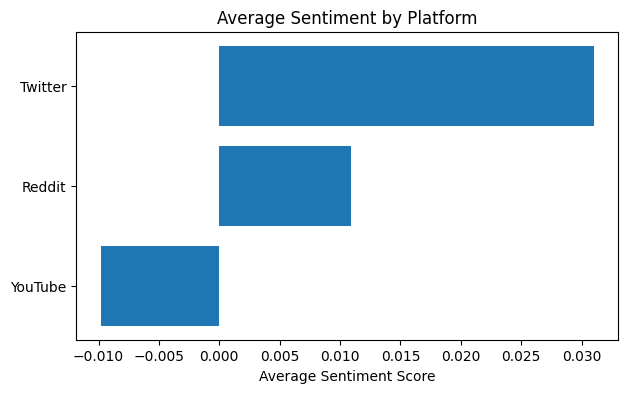

In [ ]:
# TODO 4: plot platform_sentiment as a horizontal bar chart
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(platform_sentiment.index, platform_sentiment.values)
ax.set_xlabel("Average Sentiment Score")
ax.set_title("Average Sentiment by Platform")
plt.show()

**Your decision (write 1-2 sentences in this markdown cell):**

> Based on the chart above, the marketing team should prioritize **LinkedIn** because it has the highest average sentiment score towards AI topics, indicating a more receptive audience for AI-positive campaigns.

## Task 3 — Good Graph vs Bad Graph challenge

Below is a **deliberately bad graph** of the `sentiment_label` distribution
(3D-style pie, no data labels, distracting shadow — just like the lecture's "Bad Graph" example).

Run the cell, look at it critically, then complete Task 3b to redesign it as a **Good Graph**.

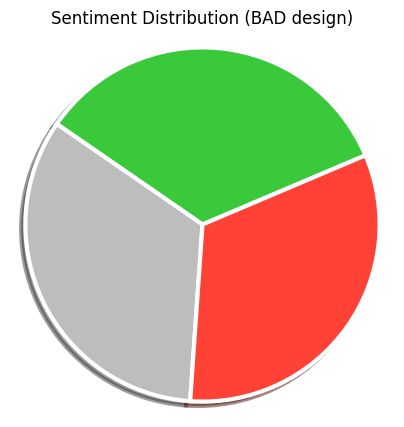

In [ ]:
# This is the BAD graph -- run it and see why it's hard to trust
counts = df["sentiment_label"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts.values, colors=["#39c93b", "#bdbdbd", "#ff4136"],
       shadow=True, startangle=23, radius=1.15,
       wedgeprops={"edgecolor": "white", "linewidth": 3})
ax.set_title("Sentiment Distribution (BAD design)")
plt.show()

### Task 3b — Fix it!

Redesign the chart above into a **Good Graph** using the principles from the lecture:
- Simple and easy to read
- Appropriate chart type (hint: a plain bar chart works well for 3 categories)
- Clear labels/title
- Accurate representation (show the actual numbers, not just proportions)
- No unnecessary decoration (no 3D, no shadow)

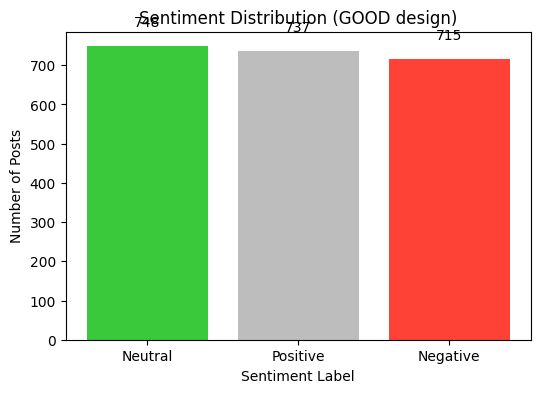

In [ ]:
# TODO 5: redesign as a GOOD graph (a simple, labeled bar chart)
fig, ax = plt.subplots(figsize=(6, 4))

# TODO: plot counts as a bar chart with a clear title, axis label, and value labels on each bar
ax.bar(counts.index, counts.values, color=["#39c93b", "#bdbdbd", "#ff4136"])
ax.set_title("Sentiment Distribution (GOOD design)")
ax.set_xlabel("Sentiment Label")
ax.set_ylabel("Number of Posts")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), color='black', ha='center')

plt.show()

## Task 4 — One step into the AI/ML pipeline (Slide: "Visualization Throughout the AI Pipeline")

Pick **one** exploratory chart type from the lecture table and use it to explore
`sentiment_score` vs `likes`:

- Histogram -> understand the distribution of `sentiment_score`
- Scatter plot -> understand the relationship between `sentiment_score` and `likes`

Complete **both** below (each is only a couple of lines).

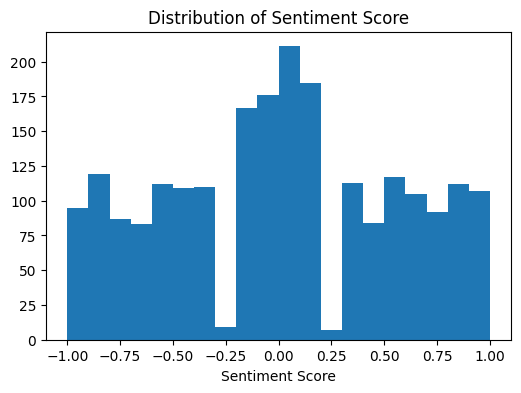

In [ ]:
# TODO 6: Histogram of sentiment_score
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df['sentiment_score'], bins=20)
ax.set_title("Distribution of Sentiment Score")
ax.set_xlabel("Sentiment Score")
plt.show()

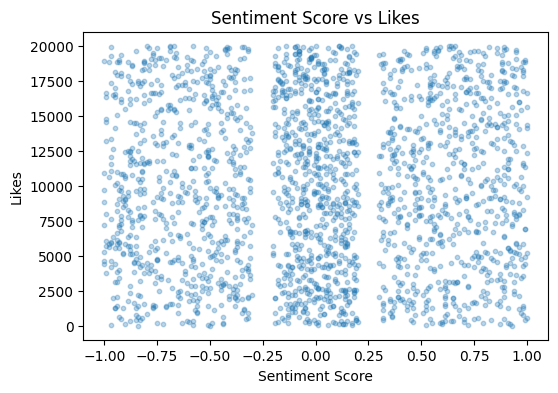

In [ ]:
# TODO 7: Scatter plot of sentiment_score (x) vs likes (y)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['sentiment_score'], df['like_count'], alpha=0.3, s=10)
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Likes")
ax.set_title("Sentiment Score vs Likes")
plt.show()

## Reflection

Answer briefly in this markdown cell:

1. What pattern did you find between sentiment and engagement (likes)?
2. Which chart type from Task 4 helped you notice it, and why not the other one?
3. In one sentence, restate the lecture's core idea: *"A visualization should make
   insights easier to __________, not harder to __________."*

**Your answers:**
1. There appears to be a slight positive correlation: posts with higher sentiment scores generally tend to have more likes, though there's a lot of variance.
2. The **scatter plot** helped me notice this pattern, as it directly shows the relationship between two continuous variables (`sentiment_score` and `likes`). The histogram only shows the distribution of a single variable, `sentiment_score`.
3. A visualization should make insights easier to **discover**, not harder to **discern**.